# <font color="steelblue">110. Análisis descritivo univariante: medidas de localización y escala</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 10/05/2025

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

## <font color='steelblue'>Introducción</font>

**Descripción:** En este cuaderno trabajamos en la descripción de variables cuantitativas aprovechando la información numérica que contienen. Recordamos en primer lugar los descriptivos numéricos que podemos extraer de modo global de un dataframe. Presentamos a continuación diversos descriptivos para ubicar los datos (tendencia central y posicionamiento), describir su dispersión o heterogeneidad (medidas de dispersión) y complementar la información sobre su distribución con medidas de forma. Planteamos a continuación cómo calcular algunos de estos descriptivos en variables ordinales y cuantitativas discretizadas, y finalizamos el cuaderno descubriendo métodos para calcular estos descriptivos de modo global sobre diferentes colectivos o estratos de la muestra.



## <font color='steelblue'> Objetivos de aprendizaje

* Comprender el alcance informativo del análisis descriptivo en variables con información cuantitativa.

* Descubrir, aplicar e interpretar medidas de posicionamiento útiles para describir la ubicación de los datos.

* Descubrir, aplicar e interpretar medidas de dispersión útiles para describir la heterogeneidad de los datos.

* Descubrir, aplicar e interpretar medidas de forma útiles para describir la distribución de los datos.

* Calcular e interpretar diversos descriptivos numéricos sobre variables ordinales y cuantitativas discretizadas.

* Calcular e interpretar medidas descriptivas para variables cuantitativas en diferentes grupos o estratos de la muestra, definidos por variables categóricas.


## <font color='steelblue'> Contenidos </font>

1. Introducción al análisis descriptivo
1. Procedimientos numéricos: Medidas de posición
1. Procedimientos numéricos: Medidas de dispersión
1. Procedimentos Gráficos
1. Procedimientos numéricos: Medidas de forma
1. Análisis descriptivo de un dataframe
1. Descriptivos para datos ordinales y numéricos discretizados

## <font color='steelblue'> 1. Introducción al análisis descriptivo

Cada vez que nos enfrentamos a un conjunto de datos, una de las primeras tareas a realizar es encontrar la manera de explorar y resumir los datos de una forma compacta y fácil de entender. En eso consiste la estadística descriptiva. De hecho, para mucha gente el término "estadística" es sinónimo de estadística descriptiva.  La **estadística descriptiva** es la piedra angular o base de la Ciencia de Datos y puede definirse como el conjunto de técnicas y medidas que resumen unos datos registrados, para comprenderlos y descubrir patrones y características útiles para un primer informe, y después para abordar un análisis estadístico más exhaustivo y formal.


En el cuaderno anterior presentamos las tablas de frecuencias, útiles para contar sujetos u ocurrencias e identificar relaciones entre variables de tipo categórico. Se trata pues, de una herramienta descriptiva para variables categóricas.

Cuando tenemos **variables con información cuantitativa**, ya hemos visto que podemos discretizarlas en intervalos, y entonces resumirlas con tablas de frecuencias. Sin embargo, utilizando la información cuantitativa que contienen podemos extraer una mejor descripción a través de medidas descriptivas que caracterizan meridianamente bien su comportamiento y complementan la información que se deriva del cálculo de frecuencias. Dependiendo del propósito descriptivo, estas medidas se clasifican en *medidas de tendencia central, de localización, de forma y de dispersión*, entre las que destacamos habitualmente:

- las **medidas de tendencia central** da indicaciones sobre los valores en torno a los que se distribuyen los datos, como la media, la mediana y la moda;
- las **medidas de localización o posición** añaden información sobre cómo se van repartiendo los datos, desde el mínimo valor hasta el máximo, pasando por cuartiles y percentiles; realmente, las medidas de tendencia central son medidas de localización, puesto que localizan el centro de los datos, por lo que las trataremos bajo esta denominación;
- las **medidas de dispersión** informan sobre la heterogeneidad o variabilidad de los valores observados en la variable de interés;
- por último, las **medidas de forma** indican la forma de la distribución de los datos al representarlos, esto es, si es más o menos simétrica o apuntada.

Nos centramos en este cuaderno en estas medidas descriptivas para variables numéricas o cuantitativas, que aplicaremos también a variables de tipo ordinal y a variables cuantitativas discretizadas en intervalos.


Acabaremos el cuaderno presentando el modo de conseguir estos descriptivos para variables numéricas de forma diferenciada sobre distintos grupos de sujetos/registros clasificados por algunas otras variables categóricas en la base de datos.

De forma gráfica las medidas decriptivas para una variable cuantitativa o numérica pretenden resumir la información contenida en ella en un único valor:

![Resumen de una variable](https://raw.githubusercontent.com/jmsocuellamos/DataSeg/master/img/summary.jpg)

> *Interpretación del gráfico: Analizamos la variable identificada en la columna en amarillo del banco de datos y extraemos una medida descriptiva (casilla rosa) a partir de todos los datos registrados en las filas disponibles.*

En el caso de tener más de una variable cuantitativa podemos representar el análisis descriptivo como:

![Resumen para dos variables](https://raw.githubusercontent.com/jmsocuellamos/DataSeg/master/img/summary2.png)

> *Interpretación del gráfico: Analizamos las variables identificadas en las columnas en amarillo  y morado del banco de datos, y extraemos una medida descriptiva (casilla rosa) a partir de la información contenida en cada una de ellas.*

Como es costumbre en primer lugar crgamos todos los módulos necesarios así como los bancos de datos con los que trabajaremos. En este caso utilizaremos el banco de datos `pollution` donde a partir de la variable `Date` vamos a agregar nuevas variables al banco de datos como son `year`, `month`, y `hour`.

In [ ]:
# Cargamos módulos de análisis numérico
import numpy as np          # importamos numpy como np
import pandas as pd         # importamos pandas como pd
import math                 # importamos módulo para cáculos matemáticos

# Cargamos módulos de análisis gráficos
from plotnine import *      # importamos módulo para gráficos con ggplot
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
%config InlineBackend.figure_format = 'retina'

# Cargamos bancos de datos
url = 'https://raw.githubusercontent.com/jmsocuellamos/DataPython/main/air_pollution_seoul.csv'
pollution = pd.read_csv(url)
# Renombramos variable
pollution.rename(columns={'PM2.5': 'PM2_5'}, inplace=True)
# Convertimos formato de fecha
pollution['Date'] = pd.to_datetime(pollution['Date'])
# y podemos definir año, mes y hora
pollution['year'] = pollution['Date'].dt.year.astype('category')
pollution['month'] = pollution['Date'].dt.month.astype('category')
pollution['hour'] = pollution['Date'].dt.hour.astype('category')

## <font color='steelblue'> 2. Procedimientos numéricos: Medidas de posición

Nos concentramos en estudiar en detalle los descriptivos relacionados con la tendencia central y posicionamiento en variables numéricas.

Las medidas de posición nos ayudan a comprender dónde se ubican los datos, identificando:
- el centro, en torno al cual están repartidos los datos: media y mediana;
- la zona/punto en la que se concentran la mayoría de los datos: moda
- los valores extremos, entre los que están todos los datos: mínimo y máximo
- valores intermedios que marcan fronteras relevantes, acumulando cierto porcentaje de los datos a un lado: cuartiles y percentiles.

Realmente la media, mediana y moda se suelen aludir como *medidas de tendencia central*, pues identifican posiciones centrales de los datos. No obstante, no dejan de ser medidas de localización, y por ello las incluimos aquí.

Vamos a ir explicando en detalle cada uno de estos descriptivos mencionados.

### <font color='steelblue'>Media, mediana y moda

Comenzamos por la **media**. La media, o media muestral (ya que se calcula sobre la muestra de los datos disponibles), se denota habitualmente por $\bar{x}$, y representa el valor central del conjunto de datos, calculado teniendo en cuenta los valores observados.

Para una variable de tipo cuantitativo en el que cada registro corresponde a un sujeto diferente, la media se obtiene calculando el promedio de todos los valores disponibles, $x_1, x_2,…,x_n$, es decir, la suma de todos ellos dividida por el tamaño o número de datos disponibles:

$$\bar{x} = \frac{\sum_{i=1}^n x_i}{n}.$$

La función de **Python** que utilizamos para obtener la media de una serie de datos es `.mean()`, y prescinde de los valores faltantes sin necesidad de especificar nada.

Calculamos por ejemplo, las medias para la variables del dataframe `pollution` que contienen los valores registardos de diferentes contaminantes.


In [ ]:
# Selecionamos las variables numéricas
varnum = ["SO2","NO2","O3","CO","PM10","PM2_5"]
# Calculamos la media de todas ellas
round(pollution[varnum].mean(),2)

,0
SO2,3.79
NO2,22.22
O3,18.20
CO,0.51
PM10,43.20
PM2_5,24.64


Podemos observar los valores medios de cada contamienante para todo el conjunto de datos.

La **mediana** (o mediana muestral) señala el centro de los datos considerando solo la ordenación de los valores observados. Para calcularla se ordenan los datos de menor a mayor, y se señala como mediana el valor que deja el 50% de los datos observados por debajo de él y el otro 50% por encima. Para ser más precisos, su valor se calcula de forma distinta en función de que el número de datos de la muestra sea par o impar:

* si el número de datos observados es impar, es fácil identificar el número que, en una posición impar, ocupa el centro, y que deja el mismo número de datos a un lado y a otro;

* si es par, una vez ordenados todos los datos se calcula la mediana como la media de los dos valores centrales.

Para calcular la mediana en *Python* usamos la función `.median()`.

Reproducimos sobre un ejemplo sencillo, este cálculo. En concreto sobre dos secuencias: una impar (1,2,3,4,5) y otra par (1,2,3,4). En la primera el centro, la mediana, es el 3; en la secuencia par, la mediana es la media de los dos valores centrales, $(2+3)/2=2.5$. En ambos casos la mediana deja tantos valores por debajo como por encima, esto es, separa el 50% de los datos a uno y otro lado.

In [ ]:
# Cálculo de la mediana con un listado impar y par de datos
print("Número de datos impar, mediana=", pd.Series([3, 1, 4, 2, 5]).median())
print("Número de datos par: mediana=", pd.Series([3, 1, 4, 2]).median())

Número de datos impar, mediana= 3.0
Número de datos par: mediana= 2.5


Esta función solo aplica a datos con información numérica, incluidas las fechas, y prescinde automáticamente de los valores faltantes.

In [ ]:
# Calculamos la mediana de todas ellas
round(pollution[varnum].median(),2)

,0
SO2,4.0
NO2,21.0
O3,13.0
CO,0.5
PM10,35.0
PM2_5,19.0


Tenemos pues que el 50% de las observaciones registran valores inferios a 4 para el SO2, de 21 para el NO2, de 13 para el O3, de 0.5 para CO, y de 35 y 19 para PM10 y PM2.5 respectivamente.

Ahora viene la gran pregunta: **¿Qué medida central es recomendable utilizar: media o mediana?** Para responderla, hemos de tener en cuenta cómo se calcula cada una. La media tiene en cuenta el número de datos y también el valor de las observaciones; un promedio es muy sensible a valores extremos, es decir, los valores muy altos influyen mucho en el resultado desplazando la media hacia valores altos aunque la mayoría de los datos sean bajos, y el mismo efecto en sentido contrario se produce cuando algunos pocos valores son especialmente bajos aunque la mayoría sean altos. En esos casos la media no representaría el punto en torno al cual se encuentran todos los datos, sino que sería un punto intermedio entre la zona donde se encuentran la mayoría de las observaciones y ese punto o puntos extremos. La mediana sin embargo, solo tiene en cuenta la ordenación de los datos, por lo que es preferible a la media cuando se dan ese tipo de situaciones en las que los datos no están repartidos de modo homogéneo en una zona concreta sino que hay extremos muy diferentes al resto.

Veámoslo con un ejemplo. Tenemos un conjunto de datos que mayoritariamente están entre los valores 1 y 5, pero además hay otro dato muy alejado de estos, con valor 1000. La media toma un valor de 22.6, que no representa un centro de referencia en torno al cual están todos los datos. La mediana sin embargo, vale 4, y nos dice que el 50% de las observaciones están por debajo de este valor y el resto por encima.

In [ ]:
# cálculo de la media y la mediana para una variable con un valor extremo
datos = pd.Series([1, 5, 4, 3, 100])
print("Media de [1,3,4,5,100]: ", datos.mean())
print("Mediana de [1,3,4,5,100]: ", datos.median())

Media de [1,3,4,5,100]:  22.6
Mediana de [1,3,4,5,100]:  4.0


Por contra, cuando los datos se reparten de modo más o menos homogéneo en torno a algún valor (hablamos de que son simétricos), la media y la mediana coincidirán.

En nuestro ejemplos podemos ver como la media y la mediana se parecen bastante para muchos de los contaminentes indicando un alto grado de simetría o reparto alrededor de la media.


Otra medida de tendencia central es la **moda**, que se define como el valor más frecuente en el conjunto de datos. Se calcula con la función **`mode()`**. Este descriptivo se aplica pues, a todo tipo de variables, numéricas y categóricas.


In [ ]:
# Calculamos la mediana de todas ellas
pollution[varnum].mode()

,SO2,NO2,O3,CO,PM10,PM2_5
0,4.0,0.018,2.0,0.4,27.0,17.0


Obtenemos de esta forma el valor que más repite para cada uno de los contaminantes a lo largo del periodo de estudio.

### <font color='steelblue'> Cuantiles y familia

Cuando hablamos de localización de los datos, hay otras medidas que nos resultarán útiles al identificar valores frontera que separan un porcentaje de los datos del resto. Nos referimos a los **percentiles**. El percentil $p$ (con $p$ un valor entre 0 y 100) se define como aquel valor de la variable por debajo del cual queda el $p\%$ de la muestra. Así pues, el $(100-p) \%$ de los registros en la muestra tomarán valores por encima de él.

Los percentiles se interpretan en una escala de porcentajes, y su versión en una escala de probabilidades son los **cuantiles**. El cuantil $q$ en una muestra, con $q$ un valor entre 0 y 1, se corresponde con el percentil $p=q \times 100$.
Así, calcular el percentil $p$ será equivalente a calcular el cuantil $p/100$.


En *Python* los cuantiles se calculan con la función **`quantile()`** y utiliza como argumento un valor $q$ entre 0 y 1.
Así, el cuantil 0.9, o lo que es lo mismo, el percentil 90, se interpretará como el valor que deja el 90% de la muestra por debajo (y el 10% por encima), y se calcula con `quantile(0.9)`.

De este modo, el mínimo valor en una muestra será el cuantil 0 y el máximo el cuantil 1. Estos valores, mínimo y máximo, también los podemos calcular con las funciones `min()` y `max()` respectivamente.

Calculamos unos cuantos percentiles a continuación para la variable `bmi`.  El cuantil 0.5 es el que se calcula por defecto cuando no incluimos ningún argumento en la función `quantile()`.




In [ ]:
# Percentiles deseados
probs = [.05, .10, .25, .75, .90, .95]
# Calculamos todos los percentiles redondeando a dos decimales
round(pollution[['SO2', 'NO2', 'O3', 'CO', 'PM10', 'PM2_5']].quantile(probs),2)

,SO2,NO2,O3,CO,PM10,PM2_5
0.05,0.01,0.01,0.01,0.2,7.0,3.0
0.10,2.00,0.02,0.02,0.3,12.0,6.0
0.25,3.00,5.00,2.00,0.3,22.0,11.0
0.75,5.00,34.00,29.00,0.6,53.0,31.0
0.90,6.00,48.00,46.00,0.8,76.0,46.0
0.95,6.00,57.00,57.00,1.0,97.0,61.0


Si tomamos por ejemplo el contamienante `SO2` podemos concluir que:

* El 5% de los datos registrados tienen una valor menor o igual a 0.01 (equivalentemente el 95% tienen valores superiores a dicho valor).
* El 10% de los datos registrados tienen una valor menor o igual a 2 (equivalentemente el 90% tienen valores superiores a dicho valor).
* El 25% de los datos registrados tienen una valor menor o igual a 3 (equivalentemente el 75% tienen valores superiores a dicho valor).
* El 75% de los datos registrados tienen una valor menor o igual a 5 (equivalentemente el 25% tienen valores superiores a dicho valor).
* El 90% de los datos registrados tienen una valor menor o igual a 6 (equivalentemente el 10% tienen valores superiores a dicho valor).
* El 95% de los datos registrados tienen una valor menor o igual a 6 (equivalentemente el 5% tienen valores superiores a dicho valor).

Si como vimos en el cuaderno anterior un valor suoerior a 1 en el SO2 indica posible peligro para la salud, podemos concluir que más del 90% de las mediciones superan dicho valor.

Otra medida habitual para calcular valores frontera que dejan a un porcentaje de la muestra a un lado es la de los **cuartiles**, que secciona en cuartos el intervalo de variación de los cuantiles (y de los percentiles). Así son populares:

- primer cuartil = cuantil $0.25$ = percentil $25$
- segundo cuartil = cuantil $0.5$ = percentil $50$
- tercer cuartil = cuantil $0.75$ = percentil $75$.

Es decir, el primer cuartil secciona el primer cuarto de la muestra (ordenada), el segundo cuartil separa la muestra en dos grupos a izquierda y derecha con igual número de registros, y el tercer cuartil marca el valor frontera por debajo del cual queda el 75% de la muestra.

Si ya hemos hablado de una escala de proporción para los cuantiles, de porcentaje para los percentiles, de cuartos de fracción para los cuartiles, introducimos los **deciles** el equivalente a los anteriores en una escala de décimas, esto es:

- primer decil (decil 1) = cuantil 0.1 = percentil 10
- segundo decil (decil 2) = cuantil 0.2 = percentil 20
- tercer decil (decil 3) = cuantil 0.3 = percentil 30

 .

- octavo decil (decil 8) = cuantil 0.8 = percentil 80
- noveno decil (decil 9) = cuantil 0.9 = percentil 90

De nuevo el decil 0 representa el mínimo, y el decil 10 el máximo de la muestra. Su cálculo solo requiere cuantificarlo en cuantiles.


## <font color='steelblue'> 3. Procedimientos numéricos: Medidas de dispersión

Hasta ahora básicamente solo hemos resumido los datos utilizando medidas de posicionamiento que nos hablan de dónde está el centro de los datos, cuáles son más frecuentes, o incluso cómo se reparten porcentualmente. Sin embargo, falta añadir información sobre la heterogeneidad o variabilidad de la muestra, información que nos proporcionan las **medidas de dispersión**. Una variable muy dispersa será una variable que toma valores muy distintos entre sí, esto es, que su rango de variación es muy amplio, o lo que es lo mismo, que los sujetos medidos proporcionan mediciones muy heterogéneas entre sí.

Las medidas de dispersión permiten pues caracterizar de modo más detallado una muestra. Podría darse el caso de dos muestras ambas con una media de 50, una de ellas con un valor mínimo de 45 y uno máximo de 55, y otra con un valor mínimo de 0 y máximo de 100. Claramente la primera será más homogénea que la segunda, y para caracterizar dicha variación utilizaremos estas medidas de dispersión.

La variabilidad de una muestra es un concepto íntimamente ligado a la precisión de las conclusiones que derivamos al describirlas. En el ejemplo anterior, no nos equivocaremos mucho (seremos precisos) si decimos que las mediciones están en torno al valor 50 para la primera muestra, pero no acertaremos tanto con la segunda muestra si hacemos esta afirmación (perdemos precisión), pues es claro que tendremos valores bastante alejados de 50 a ambos lados, próximos a 0 y a 100.

En cualquier caso, las medidas de dispersión complementan los descriptivos basados en localización, aportando información que estos no dan.

Entre las medidas de dispersión que vamos a estudiar están el **rango**, el **rango intercuartílico**, la **varianza** y la **desviación típica**. También hablaremos, por avanzarnos hacia los próximos cuadernos de inferencia, del **error estándar** y de los **intervalos de dispersión**, como medidas de variabilidad. Estudiamos estas medidas con detalle a continuación.

El **rango** de una variable se calcula como la diferencia entre el valor máximo y mínimo observados, y permite cuantificar cómo de dispersos están los datos en función de si los datos se distribuyen en un rango de variación más o menos grande. Rangos grandes implican mayor variabilidad o dispersión en los datos.

No obstante, si nuestros datos están concentrados en una zona pero existen unos pocos valores extremos alejados de ellos, el rango será poco informativo a la hora de describir la dispersión de los datos. Interesará calcular también otras medidas de dispersión.

Podemos calcular el rango para todas las variables de interés is obtenemos sus valores máximo y mínimo:

In [ ]:
# Diferentes modos de seleccionar
pollution[varnum].max() - pollution[varnum].min()

,0
SO2,307.0
NO2,118.0
O3,615.0
CO,31.4
PM10,3562.0
PM2_5,986.0


Podemos ver que el rango más amplio se produce para el tamaño de las partículas (PM10 y PM2.5).

Otra medida de dispersión similar es el **rango intercuartílico**, que se calcula como la diferencia entre el tercer y primer cuartil. Representa así el rango de valores entre los que se ubica el 50% central de la muestra, esto es, los que quedan por encima del percentil 25 y por debajo del 75. Como el rango, el rango intercuartílico expresa dispersión en las unidades de medida de cada variable.

Podemos calcular todos los rangos intercuartílicos para nuestras variables de interés mediante un bucle muy sencillo:


In [ ]:
for var in varnum:
  print(var, ": Intervalo IQ =", [pollution[var].quantile(0.25), pollution[var].quantile(0.75)],
        " --> Rango IQ =",round(pollution[var].quantile(0.75)-pollution[var].quantile(0.25),2))

SO2 : Intervalo IQ = [3.0, 5.0]  --> Rango IQ = 2.0
NO2 : Intervalo IQ = [5.0, 34.0]  --> Rango IQ = 29.0
O3 : Intervalo IQ = [2.0, 29.0]  --> Rango IQ = 27.0
CO : Intervalo IQ = [0.3, 0.6]  --> Rango IQ = 0.3
PM10 : Intervalo IQ = [22.0, 53.0]  --> Rango IQ = 31.0
PM2_5 : Intervalo IQ = [11.0, 31.0]  --> Rango IQ = 20.0


Podemos ver ahora que que el 50% de las observaciones de SO2 se encunetran en un rango de dos unidades comprendido en el intervalo [3,5].

La **varianza**, o varianza muestral, (denotada por $v^2$) es la medida de variabilidad más habitual. Trata de medir cuánto varían los datos en promedio con respecto a la media muestral. Se calcula como un promedio de las distancias a la media elevadas al cuadrado (para evitar signos negativos). Más concretamente, para una muestra de tamaño _n_ con valores observados $x_1, x_2, \ldots, x_n$ y media muestral $\bar{x}$, se define la varianza muestral como:

$$v^2 = \frac{\sum_{i=1}^n (x_i - \bar{x})^2}{n}$$

Al calcularse a partir de distancias al cuadrado, nos traslada a la escala del cuadrado de la unidad de medida. Por ejemplo, en la variable `peso`, la varianza vendrá expresada en $kg^2$.

La varianza siempre toma valores mayores o iguales que cero, al ser un promedio de distanciancias al cuadrado. Si todos los datos de la muestra coinciden con la media muestral, todas las distancias son cero y por lo tanto la varianza es cero. Así, cuanto mayor es el valor de la varianza, mayor es la variabilidad de los datos en términos de distancia a la media.

Cuando trabajamos en estadística, y por motivos que estudiaremos más adelante, en lugar de utilizar esta varianza $v^2$ para expresar la dispersión, se utiliza una **varianza insesgada $s^2$** que se calcula prácticamente como la anterior, pero dividiendo la suma de distancias al cuadrado por el número de datos menos uno ($n-1$), en lugar de por el número de datos $n$:

$$s^2 = \frac{\sum_{i=1}^n (x_i - \bar{x})^2}{n-1}$$

Cuando trabajamos con muestras grandes, la diferencia entre la varianza sesgada $v^2$ y la insesgada $s^2$ es mínima, si bien se suele utilizar siempre la insesgada $s^2$. Para obtener esta varianza en *Python* usamos la función `var()`. Si queremos calcular la varianza sesgada $v^2$ basta añadir el argumento `ddof=0`.

La calculamos para las variables numéricas.

In [ ]:
# Cálculo de la varianza (insesgada) para las variables numéricas
print("Varianza insesgada")
print(pollution[varnum].var())
print("-----------------------")
print("Varianza sesgada")
print(pollution[varnum].var(ddof=0))

Varianza insesgada
SO2         9.322301
NO2       344.299481
O3        388.537333
CO          0.145500
PM10     4507.246185
PM2_5    1137.296972
dtype: float64
-----------------------
Varianza sesgada
SO2         9.322215
NO2       344.296290
O3        388.533732
CO          0.145498
PM10     4507.204406
PM2_5    1137.286430
dtype: float64


En este caso (y debido al gran numero de observaciones) ambas mediciones son muy similares. Podemos destacara que la varaibles que muestran una mayr variabilidad son las de partículas, mientars que `CO` y `SO2` son las que muestran menos variabilidad.

Otra medida de dispersión que trata de buscar una interpretación en la escala de la variable base, es la **desviación típica** o **desviación estándar**, que no es sino la raíz cuadrada de la varianza (insesgada):
$$s = \sqrt{s^2}$$

La desviación típica es una medida de dispersión alternativa expresada en las mismas unidades de los datos de la variable objeto de estudio y, como la varianza, toma valores mayores o iguales que cero.

Así, la desviación típica de la variable `peso` se expresa en kilogramos, y no en kilogramos al cuadrado como con la varianza.


En **Python** podemos calcularla directamente con la función `datos.std()` o aplicando la raíz cuadrada a la varianza (insesgada $s^2$), que se calcula con la función `sqrt()` de *Numpy*. La versión de desviación típica basada en la varianza sesgada $v^2$ se obtiene, como antes, con el argumento `ddof=0`.

In [ ]:
# Cálculo de la desviación típica en las variables numéricas
print(pollution[varnum].std())
print("-------------------------\n")
# cálculo de la desviación típica con la raíz de la varianza
print(np.sqrt(pollution[varnum].var()))

SO2       3.053244
NO2      18.555309
O3       19.711350
CO        0.381444
PM10     67.136027
PM2_5    33.723834
dtype: float64
-------------------------

SO2       3.053244
NO2      18.555309
O3       19.711350
CO        0.381444
PM10     67.136027
PM2_5    33.723834
dtype: float64


Se aprecia claramente al disminución en la magnitud pero seguimos observando que las variables de partículas son las que tienen una dispersión más alta, es decir, las observaciones registradas varían más que en el resto de variables.

Por último, aunque el **error estándar** es una medida que se utiliza básicamente en inferencia estadística, esto es, cuando extrapolamos conclusiones a la población de la que proviene la muestra, conviene introducirla también como medida de dispersión.

El error estándar se define como el cociente entre la desviación típica y la raíz cuadrada del número de datos en la muestra, y se utiliza habitualmente para dar una medida del error admisible cuando aproximamos con una media muestral el verdadero valor de la media en la población de referencia:

$$SE_{\bar{x}} = \frac{s}{\sqrt{n}}$$

El error estándar se utiliza habitualmente para dar una medida del error admisible en la utilización de la media muestral como estimación de una media poblacional.


Para calcularlo, simplemente dividimos la desviación típica (o estándar) por la raíz cuadrada del número de datos, que calculamos con la función `count()`.

In [ ]:
# Cálculo del error estándar de las variables numéricas
pollution[varnum].std()/np.sqrt(pollution[varnum].count())

,0
SO2,0.009296
NO2,0.056493
O3,0.060013
CO,0.001161
PM10,0.204400
PM2_5,0.102674


A la hora de interpretarlo, si la varianza $s^2$ es un promedio de distancias al cuadrado a la media, el error estándar se convierte en un promedio de distancias a la media.




Hablamos del **intervalo de dispersión** en datos normales, como un intervalo que, construido a partir de la media y la desviación típica, permite cuantificar qué porcentaje de los datos están incluidos en él.

Aunque esto suena un poquito a magia (la magia de la probabilidad que estudiaremos más adelante), efectivamente podemos afirmar que, si los datos son normales:
- el intervalo  $(\bar{x}-s, \bar{x}+s)$ contiene aproximadamente el 68% de los datos, o lo que es lo mismo, el 68% de los datos están a una desviación estándar de su media;
- el intervalo $(\bar{x}-2s, \bar{x}+2s)$ contiene aproximadamente el 95% de los datos, o lo que es lo mismo, el 95% de los datos están a dos desviaciones estándar de su media.

## <font color='steelblue'> 4. Procedimentos Gráficos

Los procedimientos gráficos más habituales para la descripción de variables de tipo cuantitativo son:

* el histograma,
* el diagrama de cajas.

### <font color='steelblue'> Histograma

Es el gráfico más habitual para variables cuantitativas. Representa la distribución de los datos, agrupándolos en intervalos y mostrando las frecuencias o número de datos en cada intervalo a través de barras.

Para una mejor interpretación de este gráfico se suelen normalizar los conteos para que el área del histograma sume 1. De esta forma podemos conocer cómo se distribuyen los datos a lo largo del rango de valores posibles.

Para realizar este gráfico utilizamos la función:

* **`sns.histplot(datos, x = variable)`**

Veamos a continuación los histogramas correspondientes a las varaibles de contaminación ambiental de la base de datos `pollution`.

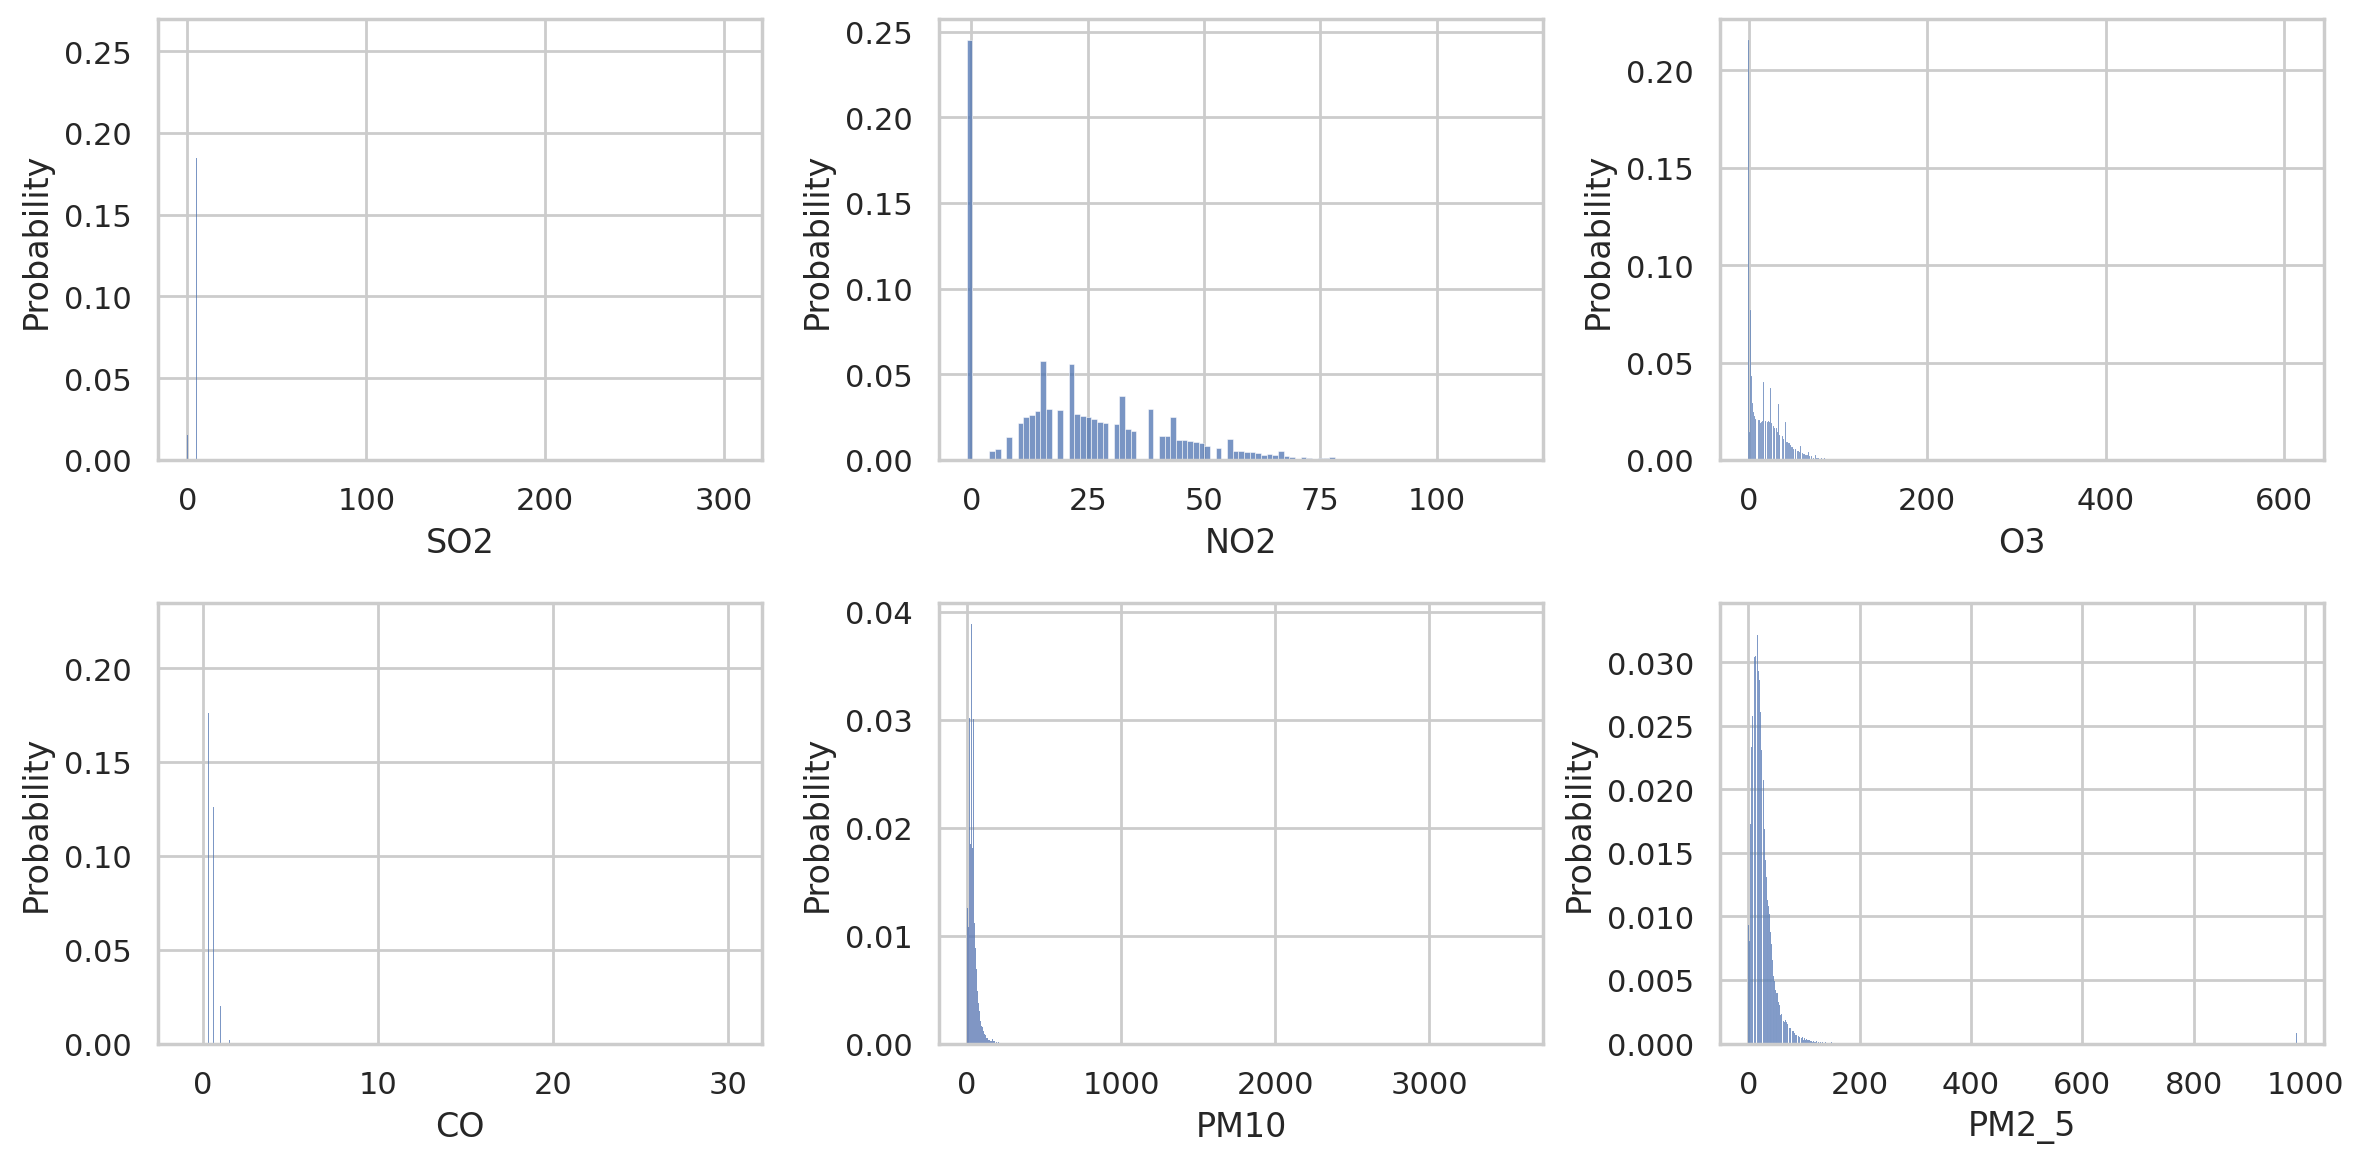

In [ ]:
sns.set_theme(style="whitegrid")

# Definimos el tamaño y estilo del gráfico
fig = plt.figure(figsize=(12, 6))

plt.subplot(2,3,1)
sns.histplot(pollution, x = "SO2", stat="probability")
plt.subplot(2,3,2)
sns.histplot(pollution, x = "NO2", stat="probability")
plt.subplot(2,3,3)
sns.histplot(pollution, x = "O3", stat="probability")
plt.subplot(2,3,4)
sns.histplot(pollution, x = "CO", stat="probability")
plt.subplot(2,3,5)
sns.histplot(pollution, x = "PM10", stat="probability")
plt.subplot(2,3,6)
sns.histplot(pollution, x = "PM2_5", stat="probability")

# Ajustamos los gráficos
plt.tight_layout()

Dado que la mayoría de las variables en este banco de datos tienen valores muy extremos, hecho que se manifiesta en el rango de variación del eje horizontal, resulta más complicado apreciar el comportamiento de los datos a través de los histogramas, especialmente en las variables `SO2` y `CO`.

Para mejorar la visualización podríamos modificar la escala del eje X para cada variable, con el fin de dejar fuera del gráfico los valores más alejados del grueso de los datos (extremos).

Para mostrar un ejemplo más interesante cargamos el banco de datos `iris` y representamos las variables numéricas.

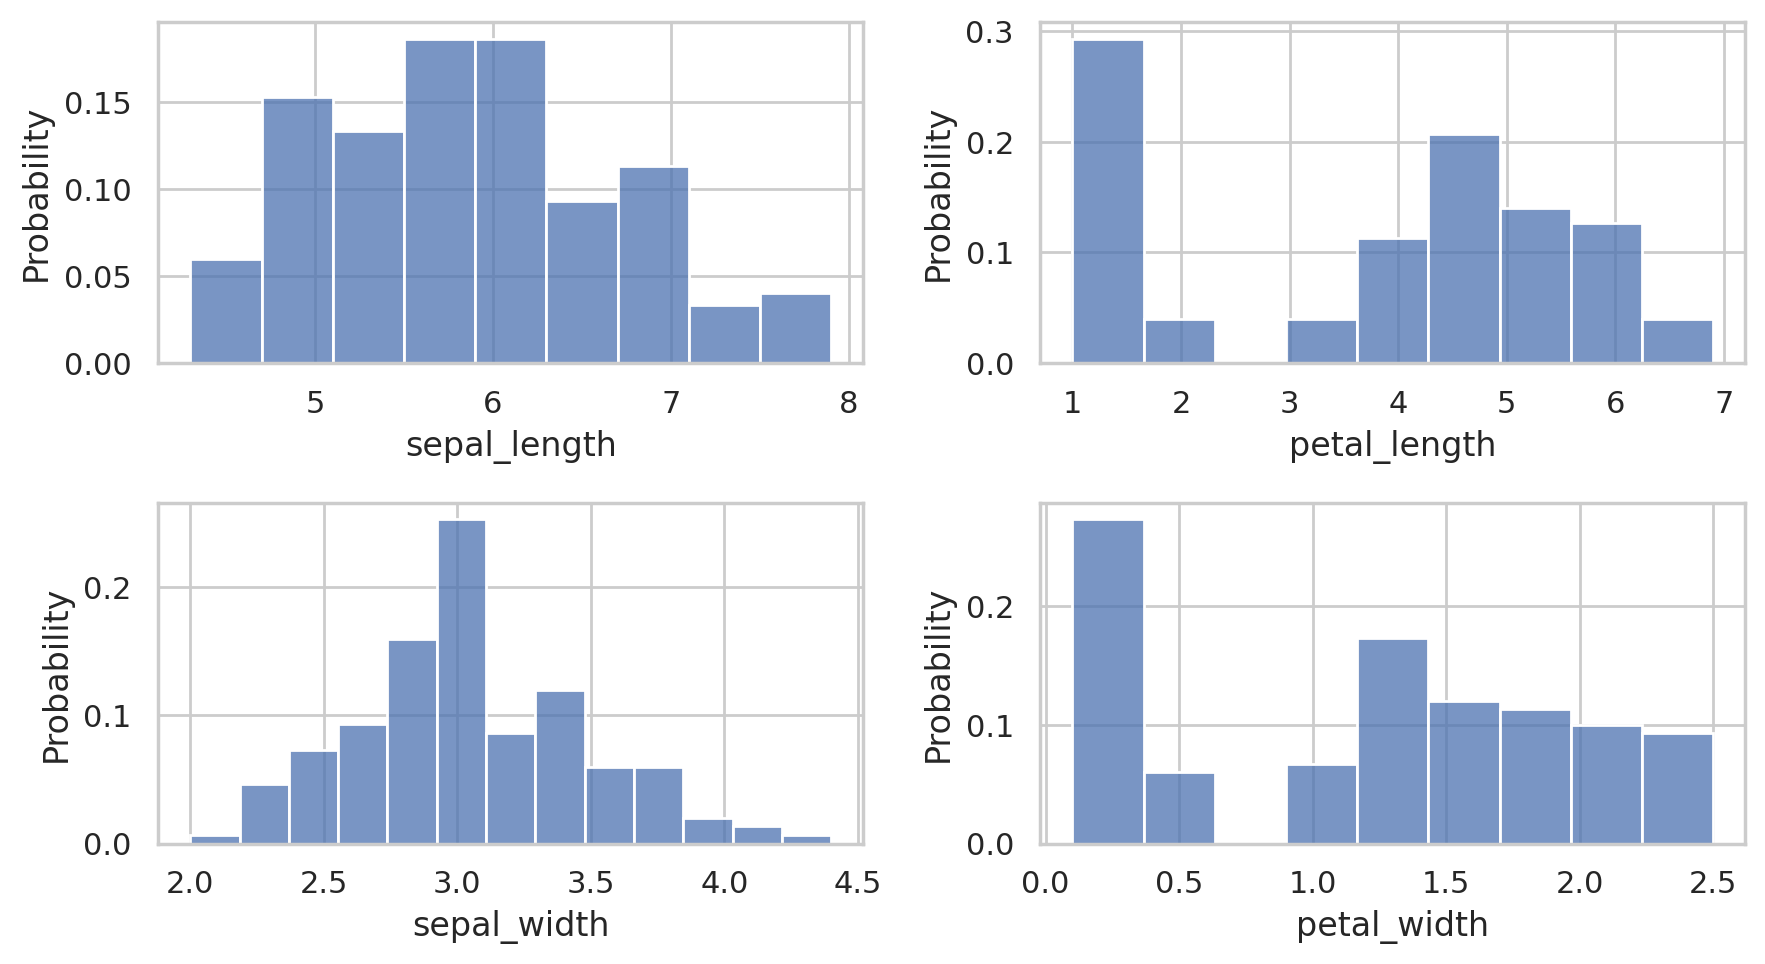

In [ ]:
# Carga de datos 'iris'
url = 'https://raw.githubusercontent.com/jmsocuellamos/DataPython/main/IRIS.csv'
iris = pd.read_csv(url)
# Histograma de variables
# Definimos el tamaño y estilo del gráfico
fig = plt.figure(figsize=(9, 5))

plt.subplot(2,2,1)
sns.histplot(iris, x = "sepal_length", stat="probability")
plt.subplot(2,2,2)
sns.histplot(iris, x = "petal_length", stat="probability")
plt.subplot(2,2,3)
sns.histplot(iris, x = "sepal_width", stat="probability")
plt.subplot(2,2,4)
sns.histplot(iris, x = "petal_width", stat="probability")

# Ajustamos los gráficos
plt.tight_layout()

En este caso si podemos apreciar claramente al distribución de cada una de las variables. De hecho, se aprecia un comportamiento claramente simétrico en `sepal_width` y `sepal_length`, mientras que en las otros dos se aprecían como dos grupos diferenciados.

### <font color='steelblue'> Diagrama de cajas

El otro gráfico común para una variable de tipo numérico es el llamado gráfico de cajas. En este gráfico los datos se representan mediante una caja y bigotes que emergen de ella.
La caja está delimitada por los percentiles 25 y 75, y aparece una línea central que representa la mediana. Entre el percentil 25 y el valor mínimo, y entre el percentil 75 y el valor máximo se traza una línea o bigote. Sin embargo, estas líneas, para evitar el efecto ya comentado de los valores extremos, se calculan con el rango intercuartílico, IQR (percentil 75-percentil 25), y se prolongan por abajo hasta el valor 'percentil 25 - 1.5 IQR' y por arriba hasta el valor 'percentil 75 + 1.5 IQR'. Los valores más extremos, más allá de estos valores y hasta el mínimo y el máximo respectivamente, se representan con puntos.

Se construye con la función

* **`sns.boxplot(data = datos, x = variable)`**

Este gráfico aporta más información que el histograma, ya que además de visualizar la distribución de los datos, añade descriptivos numéricos como los cuartiles, mínimos y máximos.
Más adelante veremos lo útiles que resultan para identificar poblaciones distintas en las que se mide una misma variable de tipo cuantitativo.

En este caso nos centramos en el dataframe `iris` para mostrar los resultados

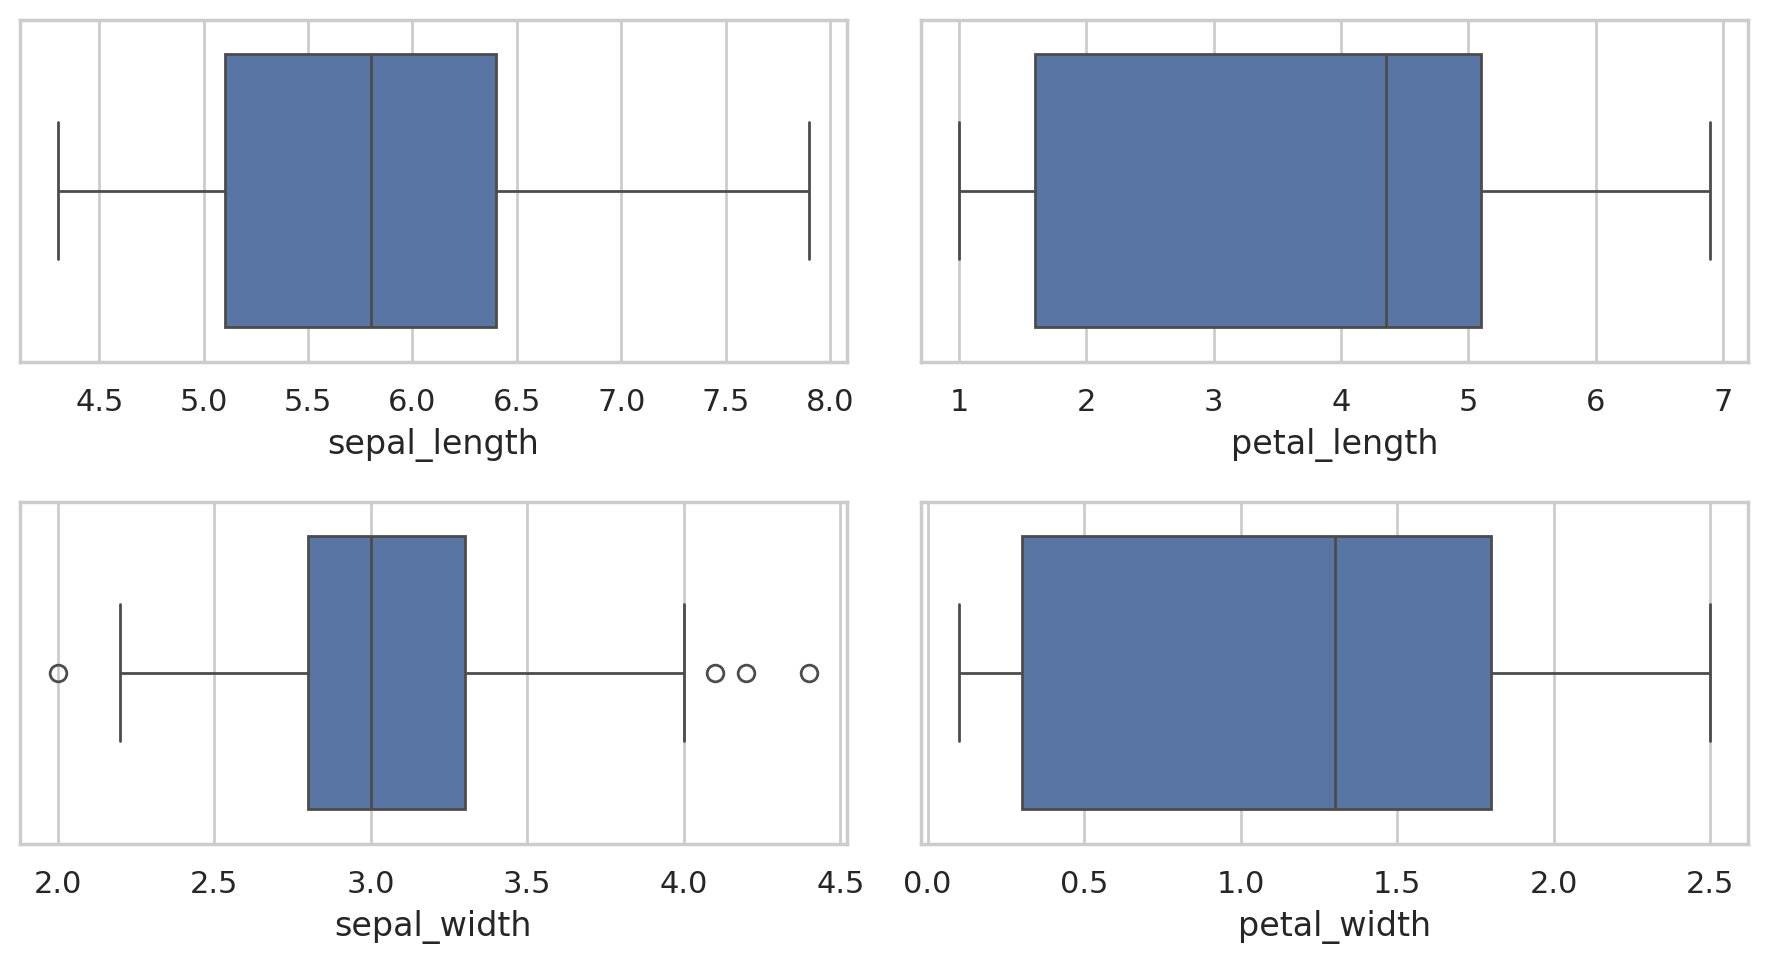

In [ ]:
# Definimos el tamaño y estilo del gráfico
fig = plt.figure(figsize=(9, 5))

plt.subplot(2,2,1)
sns.boxplot(iris, x = "sepal_length")
plt.subplot(2,2,2)
sns.boxplot(iris, x = "petal_length")
plt.subplot(2,2,3)
sns.boxplot(iris, x = "sepal_width")
plt.subplot(2,2,4)
sns.boxplot(iris, x = "petal_width")

# Ajustamos los gráficos
plt.tight_layout()

Como conclusiones, destacamos las siguientes:

* La simetría se identifica a través de la distancia entre los cuartiles, esto es las líneas en las cajas; de nuevo apreciamos la asimetría en los gráficos de 'pétalo'.
* En los gráficos 'Sepal' los datos están bastante concentrados en torno a la mediana, como lo muestra el ancho de la caja, mientras que la dispersión es mayor para los datos 'Petal'.  
* La variable con menor dispersión parece ser `Sepal_width`, pero también es la única en la que se visualizan valores extremos.

## <font color='steelblue'> 5. Análisis descriptivo de un dataframe

Comenzamos recordando algunos métodos básicos de los _dataframes_ del módulo **Pandas** que ya utilizamos en cuadernos previos, con los que conseguir de modo directo un análisis descriptivo básico para variables de tipo cuantitativo.

- **`.shape`** proporciona la dimensión del dataframe, esto es, el número de registros (filas) y variables (columnas);
- **`.info()`** da una información básica sobre las variables en el dataframe, el número de registros no nulos y el tipo de las variables;
- **`.describe()`** aplica por defecto a las variables cuantitativas de un dataframe y calcula algunos descriptivos básicos como el número de datos no nulos, la media, desviación típica y cuartiles (entre los que están el mínimo y el máximo); aplicado a las variables cualitativas (con el argumento `include=['object']`) calcula conteos, número de categorías o respuestas posibles, categoría con mayor representación y número de registros asociados a la misma. Con el argumento `include="all"` proporciona todos los descriptivos mencionados anteriormente, y rellena con `NaN` los descriptivos no evaluados según el tipo de variable.


Estos métodos proporcionan pues, de modo directo y de modo global al aplicarlo a un dataframe, unos descriptivos básicos.


In [ ]:
# Dimensión del dataframe
pollution.shape

(107882, 16)

Hablamos de que contamos con una base de datos con 107882 registros  y 10 columnas que corresponden a las 16 variables.


In [ ]:
# Información sobre la tipología de las variables y el número de datos no nulos
pollution.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107882 entries, 0 to 107881
Data columns (total 16 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Date       107882 non-null  datetime64[ns]
 1   Station    107882 non-null  int64         
 2   Address1   107882 non-null  int64         
 3   Address2   107882 non-null  object        
 4   Address3   107882 non-null  object        
 5   Latitude   107882 non-null  float64       
 6   Longitude  107882 non-null  float64       
 7   SO2        107882 non-null  float64       
 8   NO2        107882 non-null  float64       
 9   O3         107882 non-null  float64       
 10  CO         107882 non-null  float64       
 11  PM10       107882 non-null  float64       
 12  PM2_5      107882 non-null  float64       
 13  year       107882 non-null  category      
 14  month      107882 non-null  category      
 15  hour       107882 non-null  category      
dtypes: category(3), date

Este método identifica qué variables son numéricas ('int64'  y 'float64'), cuáles son cualitativas ('object') y cuál es una fecha ('datetime64[ns]').


In [ ]:
# Descriptivos básicos para las variables numéricas de un dataframe
pollution.describe()

,Date,Station,Address1,Latitude,Longitude,SO2,NO2,O3,CO,PM10,PM2_5
count,107882,107882.000000,107882.000000,107882.000000,107882.000000,107882.000000,107882.000000,107882.000000,107882.000000,107882.000000,107882.000000
mean,2018-06-27 16:02:49.551917568,113.000185,102.318765,37.553483,126.989341,3.787056,22.218233,18.196674,0.507673,43.196446,24.635129
min,2017-01-01 00:00:00,101.000000,6.000000,37.452357,126.835151,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2017-09-27 12:00:00,107.000000,17.000000,37.517528,126.927102,3.000000,5.000000,2.000000,0.300000,22.000000,11.000000
50%,2018-06-24 06:00:00,113.000000,43.000000,37.544962,127.004850,4.000000,21.000000,13.000000,0.500000,35.000000,19.000000
75%,2019-03-30 06:00:00,119.000000,71.000000,37.584848,127.047470,5.000000,34.000000,29.000000,0.600000,53.000000,31.000000
max,2019-12-31 18:00:00,125.000000,571.000000,37.658774,127.136792,306.000000,117.000000,614.000000,30.400000,3561.000000,985.000000
std,NaN,7.211393,145.553941,0.053273,0.078790,3.053244,18.555309,19.711350,0.381444,67.136027,33.723834


o

In [ ]:
pollution[varnum].describe()

,SO2,NO2,O3,CO,PM10,PM2_5
count,107882.000000,107882.000000,107882.000000,107882.000000,107882.000000,107882.000000
mean,3.787056,22.218233,18.196674,0.507673,43.196446,24.635129
std,3.053244,18.555309,19.711350,0.381444,67.136027,33.723834
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,3.000000,5.000000,2.000000,0.300000,22.000000,11.000000
50%,4.000000,21.000000,13.000000,0.500000,35.000000,19.000000
75%,5.000000,34.000000,29.000000,0.600000,53.000000,31.000000
max,306.000000,117.000000,614.000000,30.400000,3561.000000,985.000000


Conseguimos con `describe()` y sus argumentos por defecto, los descriptivos básicos de las variables numéricas. También podemos mostrar de modo diferenciado los descriptivos básicos de las variables categóricas, con el argumento `include='object'`. Estos están basados en conteos, identificación de la categoría con más registros y su conteo.

In [ ]:
# Descriptivos básicos para las variables cualitativas de un dataframe
pollution.describe(include = 'object')

,Address2,Address3
count,107882,107882
unique,25,25
top,Jong-ro 35ga-gil,Jongno-gu
freq,4317,4317


Si utilizamos el argumento `include='all'` se genera una tabla que combina las dos anteriores, rellenando con `NaN` los descriptivos no compartidos entre variables numéricas y cualitativas.

In [ ]:
# Descriptivos básicos para todas las variables de un dataframe
pollution.describe(include = 'all')

,Date,Station,Address1,Address2,Address3,Latitude,Longitude,SO2,NO2,O3,CO,PM10,PM2_5,year,month,hour
count,107882,107882.000000,107882.000000,107882,107882,107882.000000,107882.000000,107882.000000,107882.000000,107882.000000,107882.000000,107882.000000,107882.000000,107882.0,107882.0,107882.0
unique,NaN,NaN,NaN,25,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,12.0,5.0
top,NaN,NaN,NaN,Jong-ro 35ga-gil,Jongno-gu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,10.0,6.0
freq,NaN,NaN,NaN,4317,4317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36501.0,9300.0,27041.0
mean,2018-06-27 16:02:49.551917568,113.000185,102.318765,NaN,NaN,37.553483,126.989341,3.787056,22.218233,18.196674,0.507673,43.196446,24.635129,NaN,NaN,NaN
min,2017-01-01 00:00:00,101.000000,6.000000,NaN,NaN,37.452357,126.835151,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,NaN,NaN,NaN
25%,2017-09-27 12:00:00,107.000000,17.000000,NaN,NaN,37.517528,126.927102,3.000000,5.000000,2.000000,0.300000,22.000000,11.000000,NaN,NaN,NaN
50%,2018-06-24 06:00:00,113.000000,43.000000,NaN,NaN,37.544962,127.004850,4.000000,21.000000,13.000000,0.500000,35.000000,19.000000,NaN,NaN,NaN
75%,2019-03-30 06:00:00,119.000000,71.000000,NaN,NaN,37.584848,127.047470,5.000000,34.000000,29.000000,0.600000,53.000000,31.000000,NaN,NaN,NaN
max,2019-12-31 18:00:00,125.000000,571.000000,NaN,NaN,37.658774,127.136792,306.000000,117.000000,614.000000,30.400000,3561.000000,985.000000,NaN,NaN,NaN


Como apreciamos, es poco informativa esta última tabla, al contener tantos valores faltantes, por lo que recomendamos la utilización por separado de la función `describe()` para variables cuantitativas y para las cualitativas.

## <font color='steelblue'> 6. Descriptivos para datos ordinales y numéricos discretizados

Cuando tenemos variables de tipo categórico ordinal o variables continuas categorizadas o discretizadas en intervalos, también podemos calcular algunos de los descriptivos numéricos que hemos introducido previamente.

Para hacerlo, asumimos que cada una de las categorías de respuesta es identificable con un numeral o **marca de clase**, al que nos referiremos como $mc$.

Las marcas de clase en una variable ordinal pueden ser simplemente enteros consecutivos que empiezan en el 1 (por ejemplo para identificar las respuestas al nivel de satisfacción con un servicio, 1 puede ser *Muy insatisfecho*, 2=*Insatisfecho*, 3=*Ni satisfecho ni insatisfecho, 4=*Satisfecho* y 5=*Muy satisfecho*). En una variable continua discretizada en intervalos, la marca de clase será el valor central del intervalo, o lo que es lo mismo, el valor promedio de los extremos; por ejemplo, un intervalo $[0,10]$ tendrá como marca de clase el valor central, esto es, $(0+10)/2=5$.

Así mismo, al tratarse de respuestas de tipo discreto, con solo unas pocas respuestas posibles, podemos contar las frecuencias (absolutas o relativas) asociadas a cada clase o respuesta.

Resumiendo, hablamos de $k$ respuestas posibles en una variable ordinal, o continua agrupada en intervalos, cada una de ellas identificada con su marca de clase $\{mc_i, i=1,...,k\}$ y con una frecuencia relativa observada $\{f_i, i=1,...,k\}$. Con estos valores podemos calcular:

- la **media** como el promedio de las marcas de clase ponderadas por las frecuencias relativas, esto es,
$$\bar{x}_p = \sum_{i=1}^k mc_i \cdot f_i,$$

- la **varianza** como la media ponderada (por las frecuencias relativas) de las distancias al cuadrado entre las marcas de clase y la media,

$$s^2_p = \sum_{i=1}^k (mc_i - \bar{x}_p)^2 \cdot f_i,$$

- la **desviación típica** como la raíz cuadrada de la varianza:

$$s_p = \sqrt{s^2_p}$$

Para realizar estos cálculos, basados en promedios ponderados, utilizamos la función **`average(valores,weights=pesos)`** del módulo _NumPy_, que calcula promedios ponderados de los valores proporcionados, ponderándolos por los pesos especificados en el argumento `weights`.

Veamos cómo proceder primero con variables de tipo ordinal, y luego con variables numéricas agrupadas en intervalos.



### <font color='steelblue'> Datos ordinales

Cuando queremos utilizar la información ordinal vinculada a una variable categórica en un dataframe, hemos de seguir el siguiente proceso:
1. hacer una *conversión* de la variable que reconozca el orden lógico de las respuestas,
1. calcular las marcas de clase y las frecuencias
1. realizar los cálculos pertinentes para calcular los descriptivos.

Lo primero, el convertir una variable de tipo `object` a variable ordinal, esto es, tipo `category`, lo conseguimos con la función de _Pandas_ **`api.types.CategoricalDtype(orden, ordered=True)`**, que recibe como primer argumento (`orden`) una lista ordenada con las respuestas de la variable a tratar.

Lo ponemos en práctica con las variables donde trabajaremos con la variable `Dalc` del dataframe `alcohol`, que representa el consumo de alcohol en días de trabajo, *workday alcohol consumption*, con niveles desde 1=*very low* hasta 5=*very high*.

In [ ]:
# Cargamos los datos 'alcohol'
url = 'https://raw.githubusercontent.com/jmsocuellamos/DataPython/main/student-mat.csv'
alcohol = pd.read_csv(url)

Veamos como construir el factor ordinal

In [ ]:
# 1. Conversión de una variable 'object' a categórica ordinal 'category'

# creamos una lista con el orden deseado
orden = [1,2,3,4,5]
# creamos la categorización con los niveles ordenados anteriores
cat_dtype = pd.api.types.CategoricalDtype(orden, ordered = True)
# convertimos la variable Dalc en una variable 'ordinal'
alcohol["Dalc"] = alcohol["Dalc"].astype(cat_dtype)
# verificamos que los niveles de respuesta están ordenados
print(alcohol["Dalc"].head())

0    1
1    1
2    2
3    1
4    1
Name: Dalc, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]


Como vemos, las respuestas no varían, pero sin embargo en la última línea se listan las categorías con un separador '<' que indica el orden establecido. El tipo de la variable ha cambiado de `object` a `category`.

El siguiente paso consiste en obtener las marcas de clase y frecuencias relativas para realizar los cálculos oportunos.

Calculamos las frecuencias relativas a partir de las frecuencias absolutas con `value_counts()`, y convertimos la tabla en un dataframe para acceder más fácilmente a los valores, con las respuestas ordenadas correctamente. Después creamos una columna adicional con las marcas de clase. En este caso ya tenemso los valores codificados numéricamente, pero en caso de no tenerlas deberíamos asignar como marca de clase el 1 al primer nivel, y progresivamente los enteros sucesivos hasta llegar al último nivel.

En nuestro caso nos ayudaremos la función definida en el cuaderno anterior para obtener la tabla de frecuencias asociada a una varaible categórica con orden presestablecido. Cargamos la función:


In [ ]:
# @title Cargar funciones para la obtención de la tabla de frecuencias
def tfreq(df, varcol):
  '''
  Función para generar una tabla de frecuencias sin establecer orden

  Parámetros de entrada:
    - df: data frame
    - varcol: variable de interés sobre la que se desea obtener la tabla
            de frecuencias

  Resultados:
    Tabla de frecuencias con frecuencias absolutas, frecuencias relativas,
    y porcentajes.
  '''
  # Generamos tabla de frecuencias absolutas
  tabla = (df
          .groupby(varcol)
          .agg(Fa = (varcol, "count")) # frecuencia absoluta
          .reset_index())
  # Total de la tabla
  total = sum(tabla.Fa)
  # Frecuencias relativas
  tabla["fr"] = round(tabla["Fa"]/ total, 4)
  # porcentaje por filas
  tabla["Percent"] = round(100*tabla["fr"],2)
  return(tabla)

# Función para generar una tabla de frecuencias con orden preestablecido de
# las categorías

def tfreq_orden(df, varcol, cats_ordered):
  '''
  Función para generar una tabla de frecuencias estableciendo un orden
  para las categorías

  Parámetros de entrada:
    - df: data frame
    - varcol: variable de interés sobre la que se desea obtener la tabla
            de frecuencias
    - cats_ordered: Orden preestablecido de las categorías

  Resultados:
    Tabla de frecuencias con frecuencias absolutas, frecuencias relativas,
    y porcentajes.
  '''
  # Creamos un vector con el número de categorías
  cat_num = list(range(len(cats_ordered)))
  # Recodificamos a etiquetas numéricas
  for i in cat_num:
    df[varcol].replace({cats_ordered[i]: str(cat_num[i])}, inplace = True)
  # obtenemos la tabla de frecuencias
  tabla = tfreq(df, varcol)
  # Volvemos a las etiquetas originales
  for i in cat_num:
    tabla[varcol].replace({str(cat_num[i]): cats_ordered[i]}, inplace = True)
    df[varcol].replace({str(cat_num[i]): cats_ordered[i]}, inplace = True)
  # Devolvemos la tabla
  return(tabla)

In [ ]:
#2 Cálculo de frecuencias relativas y marcas de clase en una variable ordinal

# Obtenemos la tabla de frecuencias
tabla = tfreq_orden(alcohol, "Dalc", orden)
# Añadimos la marca de clase que en este coincide con la codificación de la variable
tabla["MC"] = orden
tabla

<ipython-input-29-15d0ad399ece>:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


<ipython-input-29-15d0ad399ece>:50: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
<ipython-input-29-15d0ad399ece>:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace

,Dalc,Fa,fr,Percent,MC
0,1,276,0.6987,69.87,1
1,2,75,0.1899,18.99,2
2,3,26,0.0658,6.58,3
3,4,9,0.0228,2.28,4
4,5,9,0.0228,2.28,5


Abordamos ahora el tercer paso: aplicar las fórmulas para calcular los descriptivos a partir de las frecuencias relativas, $f_i=$ `f_rel` y marcas de clase $mc_i=$ `Marca`, con la función `average()`.

In [ ]:
# 3. Cálculo de los estadísticos descriptivos para una variable ordinal

# media
media = np.average(tabla['MC'], weights = tabla['fr'])

# Varianza
varianza = np.average((tabla['MC']-media)**2, weights = tabla['fr'])

# Desviación típica
dt = np.sqrt(varianza)

# Valores
print("Descriptivos para la variable ordinal bmi_agrupado2")
print(f'Media: {round(media, 2)}')
print(f'Varianza: {round(varianza, 2)}')
print(f'Desviación típica {round(dt, 2)}')

Descriptivos para la variable ordinal bmi_agrupado2
Media: 1.48
Varianza: 0.79
Desviación típica 0.89


La interpretación de los resultados se hace en función de los valores numéricos asignados como marcas de clase. Así un valor de 1.48 para la media, entre el 1 y el 2, indica que el consumo medio los dias de trabajo es bajo o muy bajo. La interpretación de la varianza es complicada al estar en una escala al cuadrado, pero el valor claramente pequeño de la desviación típica comparado con la media habla de poca variabilidad o heterogeneidad entre los sujetos.

Realizamos el estudio descriptivo para la variable `smoking_status` del dataframe `stroke`.


In [ ]:
# Cargamos los datos 'stroke'
url = 'https://raw.githubusercontent.com/jmsocuellamos/DataPython/main/healthcare-dataset-stroke-data.csv'
stroke = pd.read_csv(url)
# Eiminamos la categoria "Unknown" ya que no disponemos de información
stroke2 = stroke.loc[stroke['smoking_status'] != "Unknown",:].copy()

In [ ]:
# 1. Conversión de una variable 'object' a categórica ordinal 'category'

# creamos una lista con el orden deseado
orden = ["never smoked", "formerly smoked", "smokes"]
# creamos la categorización con los niveles ordenados anteriores
cat_dtype = pd.api.types.CategoricalDtype(orden, ordered = True)
# convertimos la variable bmi_agrupado2 en una variable 'ordinal'
stroke2["smoking_status"] = stroke2["smoking_status"].astype(cat_dtype)
# verificamos que los niveles de respuesta están ordenados
print(stroke2["smoking_status"].head())

0    formerly smoked
1       never smoked
2       never smoked
3             smokes
4       never smoked
Name: smoking_status, dtype: category
Categories (3, object): ['never smoked' < 'formerly smoked' < 'smokes']


In [ ]:
#2 Cálculo de frecuencias relativas y marcas de clase en una variable ordinal

# Obtenemos la tabla de frecuencias
tabla = tfreq_orden(stroke2, "smoking_status", orden)
# Añadimos la marca de clase que en este coincide con la codificación de la variable
tabla["MC"] = [1,2,3]
tabla

<ipython-input-29-15d0ad399ece>:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


<ipython-input-29-15d0ad399ece>:50: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
<ipython-input-29-15d0ad399ece>:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pas

,smoking_status,Fa,fr,Percent,MC
0,never smoked,1892,0.5306,53.06,1
1,formerly smoked,885,0.2482,24.82,2
2,smokes,789,0.2213,22.13,3


In [ ]:
# 3. Cálculo de los estadísticos descriptivos para una variable ordinal

# media
media = np.average(tabla['MC'], weights = tabla['fr'])

# Varianza
varianza = np.average((tabla['MC']-media)**2, weights = tabla['fr'])

# Desviación típica
dt = np.sqrt(varianza)

# Valores
print("Descriptivos para la variable ordinal bmi_agrupado2")
print(f'Media: {round(media, 2)}')
print(f'Varianza: {round(varianza, 2)}')
print(f'Desviación típica {round(dt, 2)}')

Descriptivos para la variable ordinal bmi_agrupado2
Media: 1.69
Varianza: 0.66
Desviación típica 0.81


¿Cómo interpretamos los resultados obtenidos?

### <font color='steelblue'> Datos numéricos discretizados

El otro caso que comentamos es la posibilidad de que los resultados observados para una variable numérica como `edad`, no nos los proporcionen desagregados o individualizados con la edad real de cada sujeto, sino agrupados por intervalos, esto es, especificando en qué rango de edad se encuentra cada uno. Tendremos entonces como posibles respuestas una serie de intervalos en los que se ha discretizado la variable numérica, y la respuesta de cada sujeto será el intervalo en el que está incluido.

Para ejemplificar el proceso utilizamos la variable `PM10` del conjuto de datos `pollution`,  que inicialmente categorizamos en intervalos con la función `cut()`, puesto que disponemos de los datos numéricos. Los intervalos utilizados son los vistos en el cuaderno anterior. Una vez discretizada la información, asumiremos que ese es nuestro punto de arranque para iniciar el proceso de cálculo de los descriptivos para datos discretizados.


In [ ]:
# Creamos la variable discretizada edad_dis
pollution['PM10_cat'] = pd.cut(pollution.PM10, [0, 30, 80, 150, 600, pollution.PM10.max()], include_lowest = True, right = False)
# mostramos la información disponible
print(pollution['PM10_cat'].head())

0     [30.0, 80.0)
1     [30.0, 80.0)
2     [30.0, 80.0)
3     [30.0, 80.0)
4    [80.0, 150.0)
Name: PM10_cat, dtype: category
Categories (5, interval[float64, left]): [[0.0, 30.0) < [30.0, 80.0) < [80.0, 150.0) <
                                          [150.0, 600.0) < [600.0, 3561.0)]


Observamos que la variable discretizada es de tipo `category`, y las respuestas en la base de datos son el intervalo en el que está clasificado cada sujeto.

Con esta información, el procedimiento para calcular los descriptivos consistirá en:
1. convertir la variable discretizada en intervalos, generalmente de tipo `category`, a una variable de tipo `interval`, con la función `astype(type="interval")`;
1. calcular las frecuencias relativas en cada intervalo (con `value_counts()`) y las marcas de clase (con el atributo `mid` que consiguen los intervalos -como índices- al transformar la variable a tipo `interval`);
1. aplicar las fórmulas para calcular los descriptivos.

Aplicamos pues el proceso a continuación a la variable `edad_dis`. Para manipular mejor la información, la integramos en un dataframe.

In [ ]:
# 1. Convertimos la variable de intervalos a tipo 'interval'
pollution['PM10_cat'] = pollution['PM10_cat'].astype('interval')

# 2. Cálculo de frecuencias relativas y marcas de clase
# Obtenemos la tabla de frecuencias
tabla = tfreq(pollution, "PM10_cat").set_index('PM10_cat')
# Añadimos la marca de clase que en este coincide con la codificación de la variable
tabla["MC"] = tabla.index.mid
tabla

,Fa,fr,Percent,MC
PM10_cat,,,,
"[0.0, 30.0)",42172,0.3932,39.32,15.0
"[30.0, 80.0)",55377,0.5164,51.64,55.0
"[80.0, 150.0)",8472,0.0790,7.90,115.0
"[150.0, 600.0)",1061,0.0099,0.99,375.0
"[600.0, 3561.0)",165,0.0015,0.15,2080.5


In [ ]:
# 3. Cálculo de los estadísticos descriptivos para una variable numérica discretizada

# Media
media = np.average(tabla['MC'], weights = tabla['fr'])

# Varianza
varianza = np.average((tabla['MC'] - media)**2, weights = tabla['fr'])

# Desviación típica
dt = np.sqrt(varianza)

# Valores
print("\n Descriptivos para la variable discretizada edad_dis")
print(f'Media: {round(media, 2)}')
print(f'Varianza: {round(varianza, 2)}')
print(f'Desviación típica {round(dt, 2)}')

# Comparación con los descriptivos originales
print("\n Descriptivos para la variable edad")
print(f'Media: {round(pollution.PM10.mean(), 2)}')
print(f'Varianza: {round(pollution.PM10.var(), 2)}')
print(f'Desviación típica {round(pollution.PM10.std(), 2)}')


 Descriptivos para la variable discretizada edad_dis
Media: 50.22
Varianza: 8058.39
Desviación típica 89.77

 Descriptivos para la variable edad
Media: 43.2
Varianza: 4507.25
Desviación típica 67.14


Al discretizar una variable SIEMPRE perdemos información, puesto que todos los valores de un mismo intervalo quedarán representados por su valor central, los valores para los descriptivos en la variable discretizada no se alejan demasiado de los que se consiguen con los valores originales en la variable. Esto no siempre será así, especialmente cuando haya mucha dispersión y valores extremos.